# GBSR Discrete for Paper

Here, as I couldn't get something sensible out for the bit-wise reconciliation term, we simply introduce a reconciliation efficiency factor to the found mutual information.

That is, $K = 2p_\text{pass} (\eta I(T(X); T(Y_\text{PS})) - \chi)$, where $\eta$ is the reconciliation efficiency.

In [47]:
import importlib
import time
import numpy as np
from scipy.stats import norm
from scipy.optimize import Bounds, minimize, minimize_scalar
from scipy.interpolate import griddata
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LinearSegmentedColormap, Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

GBSR = importlib.reload(importlib.import_module("GBSR")).GBSR

def fibre_transmittance(distance_km, loss_db_per_km=0.2):
    """Return the channel transmittance for a fibre segment of length `distance_km`."""
    return 10 ** (-loss_db_per_km * distance_km / 10)

In [39]:
# 'Global' Parameters
# base_distance_grid = np.linspace(1, 60, 200)
# extra_distance_grid = np.linspace(30, 60, 201)  # densify the long-distance regime
# distances = np.union1d(base_distance_grid, extra_distance_grid)
distances = np.linspace(0.1, 60, 300)
#distances = np.linspace(1, 60, 50)
v_mod_bounds = (0.01, 10.0)
p_pass_bounds = (0.01, 1.0)

m1_coding_overhead_PS = 0.001
m2_coding_overhead_PS = 0.009
m3_coding_overhead_PS = 0.006

m1_coding_overhead_no_PS = 0.000
m2_coding_overhead_no_PS = 0.015
m3_coding_overhead_no_PS = 0.025

excess_noise = 0.001

## Devetak-Winter for Sanity Check

  0%|          | 0/300 [00:00<?, ?it/s]

c:\Users\Adam\miniconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8 ) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


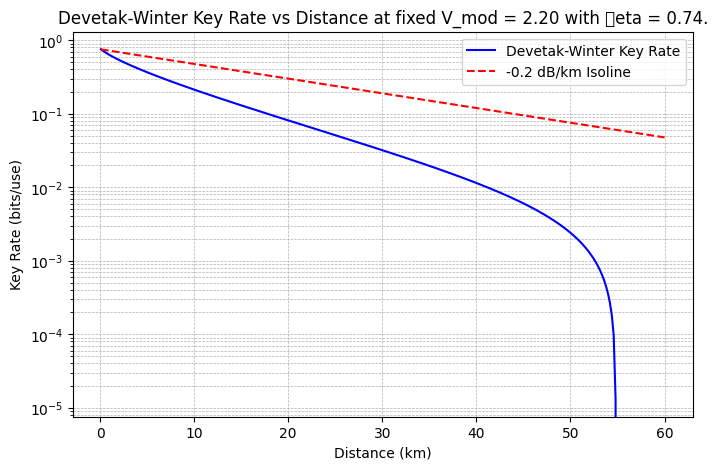

In [40]:
# Devetak-Winter sanity check with isoline at -0.2 dB/km fibre loss (fixed V_mod)

# TODO: Change the code below to not optimise over v_mod, but v_mod_dw = 2.2.

dw_code_eff = 0.74
dw_key_rates = []
v_mod_dw = 2.2

for distance in tqdm(distances):
    transmittance = fibre_transmittance(distance)

    gbsr = GBSR(
        1,
        v_mod_dw,
        transmittance,
        excess_noise,
        code_efficiency=dw_code_eff,
    )
    dw_rate = gbsr.continuous_devetak_winter
    dw_key_rates.append(dw_rate)

isoline_dw = dw_key_rates[0] * 10 ** (-0.2 * distances / 10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(distances, dw_key_rates, label="Devetak-Winter Key Rate", color="blue")
ax.plot(distances, isoline_dw, label="-0.2 dB/km Isoline", linestyle="--", color="red")
ax.set_yscale("log")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Key Rate (bits/use)")
ax.set_title(f"Devetak-Winter Key Rate vs Distance at fixed V_mod = {v_mod_dw:0.2f} with \beta = {dw_code_eff:0.2f}.")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend()
plt.show()


  0%|          | 0/300 [00:00<?, ?it/s]

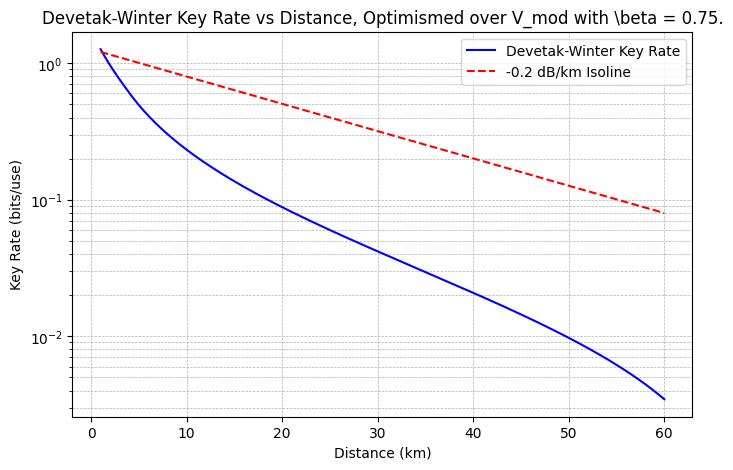

In [ ]:
# # Version with Optimisation over V_mod
# # Devetak-Winter sanity check with isoline at -0.2 dB/km fibre losss

# dw_code_eff = 0.75
# dw_key_rates = []
# v_mod_dw = 2.2

# for distance in tqdm(distances):
#     transmittance = fibre_transmittance(distance)

#     # TODO: Optimise over V_mod here
#     def objective(v_mod):
#         gbsr = GBSR(
#             1,
#             float(v_mod),
#             transmittance,
#             excess_noise,
#             code_efficiency=dw_code_eff,
#         )
#         dw_rate = gbsr.continuous_devetak_winter
#         return -dw_rate
    
#     res = minimize_scalar(
#         objective,
#         bounds=v_mod_bounds,
#         method='bounded',
#         options={'xatol': 1e-3}
#     )

#     optimal_v_mod = res.x
#     gbsr_optimal = GBSR(
#         1,
#         optimal_v_mod,
#         transmittance,
#         excess_noise,
#         code_efficiency=dw_code_eff,
#     )
#     dw_key_rate = gbsr_optimal.continuous_devetak_winter
#     dw_key_rates.append(dw_key_rate)

# isoline_dw = dw_key_rates[0] * 10 ** (-0.2 * distances / 10)

# fig, ax = plt.subplots(figsize=(8, 5))
# ax.plot(distances, dw_key_rates, label='Devetak-Winter Key Rate', color='blue')
# ax.plot(distances, isoline_dw, label='-0.2 dB/km Isoline', linestyle='--', color='red')
# ax.set_yscale('log')
# ax.set_xlabel('Distance (km)')
# ax.set_ylabel('Key Rate (bits/use)')
# ax.set_title(f'Devetak-Winter Key Rate vs Distance, Optimismed over V_mod with \\beta = {dw_code_eff:0.2f}.')
# ax.grid(True, which='both', linestyle='--', linewidth=0.5)
# ax.legend()
# plt.show()


## $m=1$ Optimal Key Efficiency over Distance 

Next, we are attempting to show what the optimal key efficiency is over distance when optimising both $p_\text{pass}$ and $V_\text{mod}$ for each distance. For the found $V_\text{mod}$, we also show the corresponding Devetak-Winter rate.

Optimising per distance:   0%|          | 0/300 [00:00<?, ?it/s]

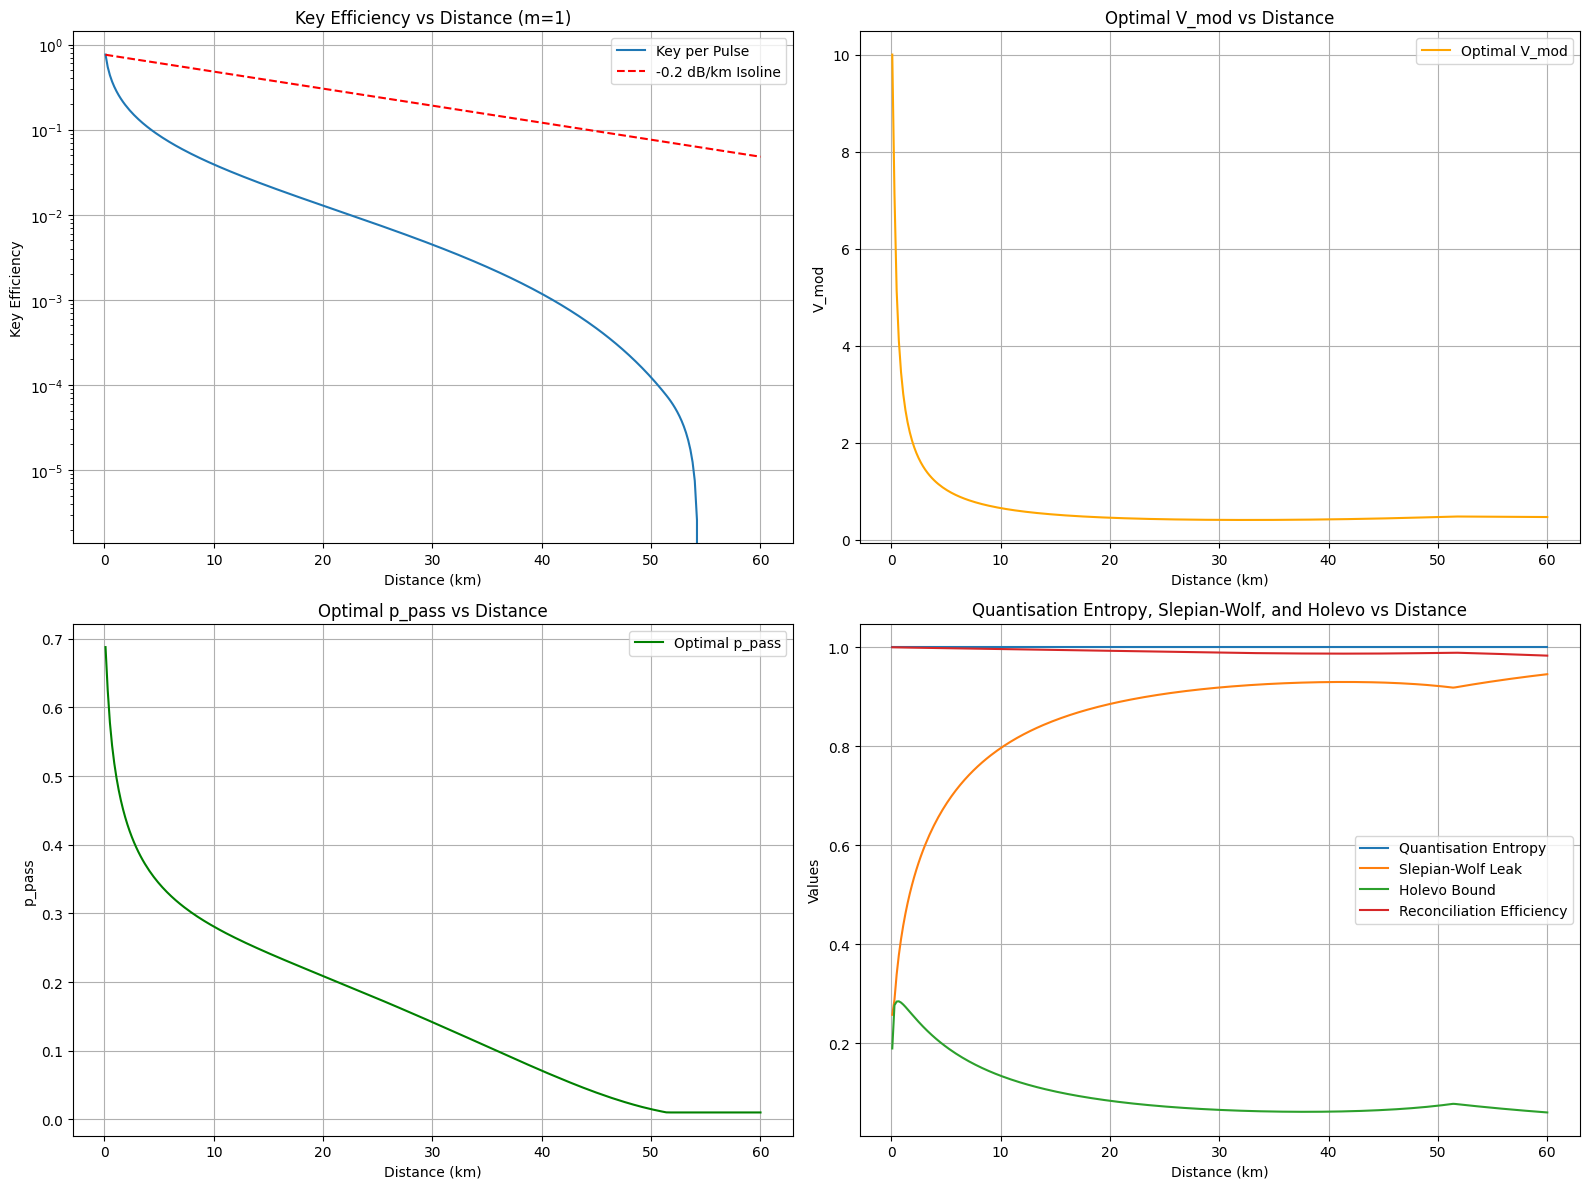

In [41]:
key_per_pulse_m1 = []
key_per_accepted_m1 = []
quantisation_entropies_m1 = []
slepian_wolf_leaks_m1 = []
holevo_bounds_m1 = []
mutual_informations_m1 = []
devetak_winters_m1 = []
optimal_v_mods_m1 = []
optimal_p_passes_m1 = []
optimal_reconciliation_efficiencies_m1 = []
optimal_metrics_m1 = []

initial_guess = np.array([np.mean(v_mod_bounds), 0.8])
bounds = [v_mod_bounds, p_pass_bounds]

for distance in tqdm(distances, desc="Optimising per distance"):
    transmittance = fibre_transmittance(distance)

    def evaluate_metrics(v_mod_candidate: float, p_pass_candidate: float):
        gbsr_instance = GBSR(
            1,
            float(v_mod_candidate),
            transmittance,
            excess_noise,
            coding_overhead=m1_coding_overhead_PS,
        )
        tau_arr = gbsr_instance.build_equiprobable_tau()
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(
            float(p_pass_candidate),
            tau_arr,
        )
        metrics = gbsr_instance.evaluate_quantised_maximum_key_efficiency(
            tau_arr,
            g_arr,
        )
        return dict(metrics), gbsr_instance

    def negative_key_per_pulse(params):
        v_mod_candidate, p_pass_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        try:
            metrics_candidate, _ = evaluate_metrics(v_mod_checked, p_pass_checked)
        except Exception:
            return np.inf
        value = float(metrics_candidate.get("key_per_pulse", -np.inf))
        if not np.isfinite(value):
            return np.inf
        return -value

    powell_result = minimize(
        negative_key_per_pulse,
        x0=initial_guess,
        method="Powell",
        bounds=bounds,
        options={"xtol": 1e-4, "ftol": 1e-9, "maxiter": 250},
    )

    polish_start = (
        powell_result.x
        if powell_result.success and np.all(np.isfinite(powell_result.x))
        else initial_guess
    )

    polish_result = minimize(
        negative_key_per_pulse,
        x0=polish_start,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 200},
    )

    if polish_result.success and np.isfinite(polish_result.fun):
        best_v_mod, best_p_pass = polish_result.x
    elif powell_result.success and np.isfinite(powell_result.fun):
        best_v_mod, best_p_pass = powell_result.x
    else:
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
        best_value = np.inf
        best_pair = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                value = negative_key_per_pulse((v_candidate, p_candidate))
                if value < best_value:
                    best_value = value
                    best_pair = (v_candidate, p_candidate)
        if best_pair is None:
            raise RuntimeError(
                f"Failed to find feasible parameters at distance {distance:.2f} km"
            )
        best_v_mod, best_p_pass = best_pair

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_metrics, best_gbsr_instance = evaluate_metrics(best_v_mod, best_p_pass)

    key_per_pulse_m1.append(best_metrics["key_per_pulse"])
    key_per_accepted_m1.append(best_metrics["key_per_accepted_symbol"])
    quantisation_entropies_m1.append(best_metrics["H_Tx_acc"])
    slepian_wolf_leaks_m1.append(best_metrics["H_Tx_given_Ty"])
    holevo_bounds_m1.append(best_metrics["holevo_bound"])
    mutual_informations_m1.append(best_metrics["I_symbol"])
    optimal_reconciliation_efficiencies_m1.append(
        best_metrics["reconciliation_efficiency"]
    )
    devetak_winters_m1.append(best_gbsr_instance.continuous_devetak_winter)
    optimal_v_mods_m1.append(best_v_mod)
    optimal_p_passes_m1.append(best_p_pass)

    optimal_metrics_m1.append(best_metrics)
    initial_guess = np.array([best_v_mod, best_p_pass])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# First subplot: key_per_pulse and devetak_winter vs distance
axes[0, 0].plot(distances, key_per_pulse_m1, label='Key per Pulse')
#axes[0, 0].plot(distances, devetak_winters_m1, label='Devetak-Winter')

# Add an isoline corresponding to a slope of -0.2 dB/km
isoline = key_per_pulse_m1[0] * 10 ** (-0.2 * distances / 10)
axes[0, 0].plot(distances, isoline, label='-0.2 dB/km Isoline', linestyle='--', color='red')

axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Key Efficiency')
axes[0, 0].set_title('Key Efficiency vs Distance (m=1)')
axes[0, 0].set_yscale('log')  # Set y-axis to log scale
axes[0, 0].legend()
axes[0, 0].grid(True)

# Second subplot: optimal V_mod over distance
axes[0, 1].plot(distances, optimal_v_mods_m1, label='Optimal V_mod', color='orange')
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('V_mod')
axes[0, 1].set_title('Optimal V_mod vs Distance')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Third subplot: optimal p_pass over distance
axes[1, 0].plot(distances, optimal_p_passes_m1, label='Optimal p_pass', color='green')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('p_pass')
axes[1, 0].set_title('Optimal p_pass vs Distance')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Fourth subplot: quantisation_entropy, slepian_wolf_leak, holevo_bound vs distance
axes[1, 1].plot(distances, quantisation_entropies_m1, label='Quantisation Entropy')
axes[1, 1].plot(distances, slepian_wolf_leaks_m1, label='Slepian-Wolf Leak')
axes[1, 1].plot(distances, holevo_bounds_m1, label='Holevo Bound')
axes[1, 1].plot(distances, optimal_reconciliation_efficiencies_m1, label='Reconciliation Efficiency')
axes[1, 1].set_xlabel('Distance (km)')
axes[1, 1].set_ylabel('Values')
axes[1, 1].set_title('Quantisation Entropy, Slepian-Wolf, and Holevo vs Distance')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


## $m = 2$

Next, we do the same as the above cell but for $m = 2$.

Optimising per distance (m=2):   0%|          | 0/300 [00:00<?, ?it/s]

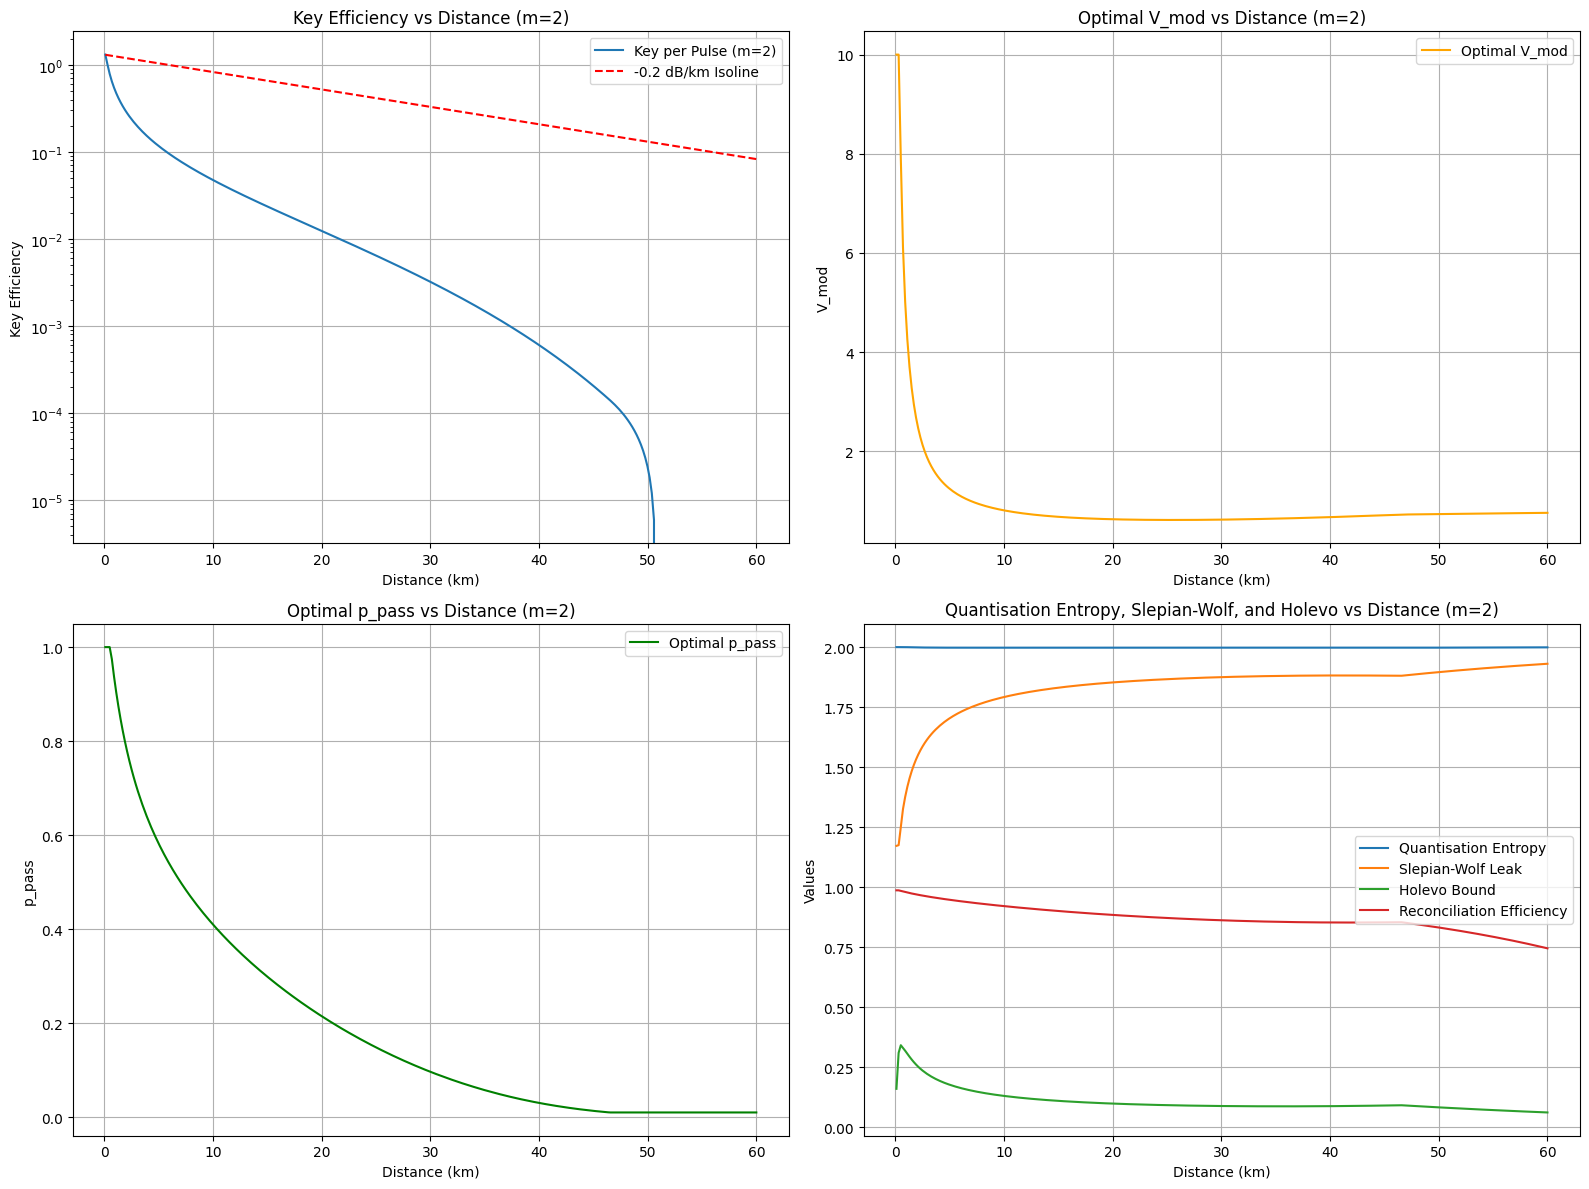

In [42]:
key_per_pulse_m2 = []
key_per_accepted_m2 = []
quantisation_entropies_m2 = []
slepian_wolf_leaks_m2 = []
holevo_bounds_m2 = []
mutual_informations_m2 = []
devetak_winters_m2 = []
optimal_v_mods_m2 = []
optimal_p_passes_m2 = []
optimal_reconciliation_efficiencies_m2 = []
optimal_metrics_m2 = []

initial_guess_m2 = np.array([np.mean(v_mod_bounds), 0.8])
bounds_m2 = [v_mod_bounds, p_pass_bounds]

for distance in tqdm(distances, desc='Optimising per distance (m=2)'):
    transmittance = fibre_transmittance(distance)

    def evaluate_metrics(v_mod_candidate: float, p_pass_candidate: float):
        gbsr_instance = GBSR(
            2,
            float(v_mod_candidate),
            transmittance,
            excess_noise,
            coding_overhead=m2_coding_overhead_PS,
        )
        tau_arr = gbsr_instance.build_equiprobable_tau()
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(
            float(p_pass_candidate),
            tau_arr,
        )
        metrics = gbsr_instance.evaluate_quantised_maximum_key_efficiency(
            tau_arr,
            g_arr,
        )
        return dict(metrics), gbsr_instance

    def negative_key_per_pulse(params):
        v_mod_candidate, p_pass_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        try:
            metrics_candidate, _ = evaluate_metrics(v_mod_checked, p_pass_checked)
        except Exception:
            return np.inf
        value = float(metrics_candidate.get('key_per_pulse', -np.inf))
        if not np.isfinite(value):
            return np.inf
        return -value

    powell_result = minimize(
        negative_key_per_pulse,
        x0=initial_guess_m2,
        method='Powell',
        bounds=bounds_m2,
        options={'xtol': 1e-4, 'ftol': 1e-9, 'maxiter': 250},
    )

    polish_start = (
        powell_result.x
        if powell_result.success and np.all(np.isfinite(powell_result.x))
        else initial_guess_m2
    )

    polish_result = minimize(
        negative_key_per_pulse,
        x0=polish_start,
        method='L-BFGS-B',
        bounds=bounds_m2,
        options={'maxiter': 200},
    )

    if polish_result.success and np.isfinite(polish_result.fun):
        best_v_mod, best_p_pass = polish_result.x
    elif powell_result.success and np.isfinite(powell_result.fun):
        best_v_mod, best_p_pass = powell_result.x
    else:
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
        best_value = np.inf
        best_pair = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                value = negative_key_per_pulse((v_candidate, p_candidate))
                if value < best_value:
                    best_value = value
                    best_pair = (v_candidate, p_candidate)
        if best_pair is None:
            raise RuntimeError(
                f"Failed to find feasible parameters at distance {distance:.2f} km for m=2"
            )
        best_v_mod, best_p_pass = best_pair

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_metrics, best_gbsr_instance = evaluate_metrics(best_v_mod, best_p_pass)

    key_per_pulse_m2.append(best_metrics['key_per_pulse'])
    key_per_accepted_m2.append(best_metrics['key_per_accepted_symbol'])
    quantisation_entropies_m2.append(best_metrics['H_Tx_acc'])
    slepian_wolf_leaks_m2.append(best_metrics['H_Tx_given_Ty'])
    holevo_bounds_m2.append(best_metrics['holevo_bound'])
    mutual_informations_m2.append(best_metrics['I_symbol'])
    optimal_reconciliation_efficiencies_m2.append(
        best_metrics['reconciliation_efficiency']
    )
    devetak_winters_m2.append(best_gbsr_instance.continuous_devetak_winter)
    optimal_v_mods_m2.append(best_v_mod)
    optimal_p_passes_m2.append(best_p_pass)
    optimal_metrics_m2.append(best_metrics)

    initial_guess_m2 = np.array([best_v_mod, best_p_pass])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(distances, key_per_pulse_m2, label='Key per Pulse (m=2)')
#axes[0, 0].plot(distances, devetak_winters_m2, label='Devetak-Winter (continuous)')

isoline_m2 = key_per_pulse_m2[0] * 10 ** (-0.2 * distances / 10)
axes[0, 0].plot(distances, isoline_m2, label='-0.2 dB/km Isoline', linestyle='--', color='red')
axes[0, 0].set_xlabel('Distance (km)')
axes[0, 0].set_ylabel('Key Efficiency')
axes[0, 0].set_title('Key Efficiency vs Distance (m=2)')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(distances, optimal_v_mods_m2, label='Optimal V_mod', color='orange')
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('V_mod')
axes[0, 1].set_title('Optimal V_mod vs Distance (m=2)')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(distances, optimal_p_passes_m2, label='Optimal p_pass', color='green')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('p_pass')
axes[1, 0].set_title('Optimal p_pass vs Distance (m=2)')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(distances, quantisation_entropies_m2, label='Quantisation Entropy')
axes[1, 1].plot(distances, slepian_wolf_leaks_m2, label='Slepian-Wolf Leak')
axes[1, 1].plot(distances, holevo_bounds_m2, label='Holevo Bound')
axes[1, 1].plot(distances, optimal_reconciliation_efficiencies_m2, label='Reconciliation Efficiency')
axes[1, 1].set_xlabel('Distance (km)')
axes[1, 1].set_ylabel('Values')
axes[1, 1].set_title('Quantisation Entropy, Slepian-Wolf, and Holevo vs Distance (m=2)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


## $m = 3$

Now, we also do the same for $m = 3$.

Optimising per distance (m=3):   0%|          | 0/300 [00:00<?, ?it/s]

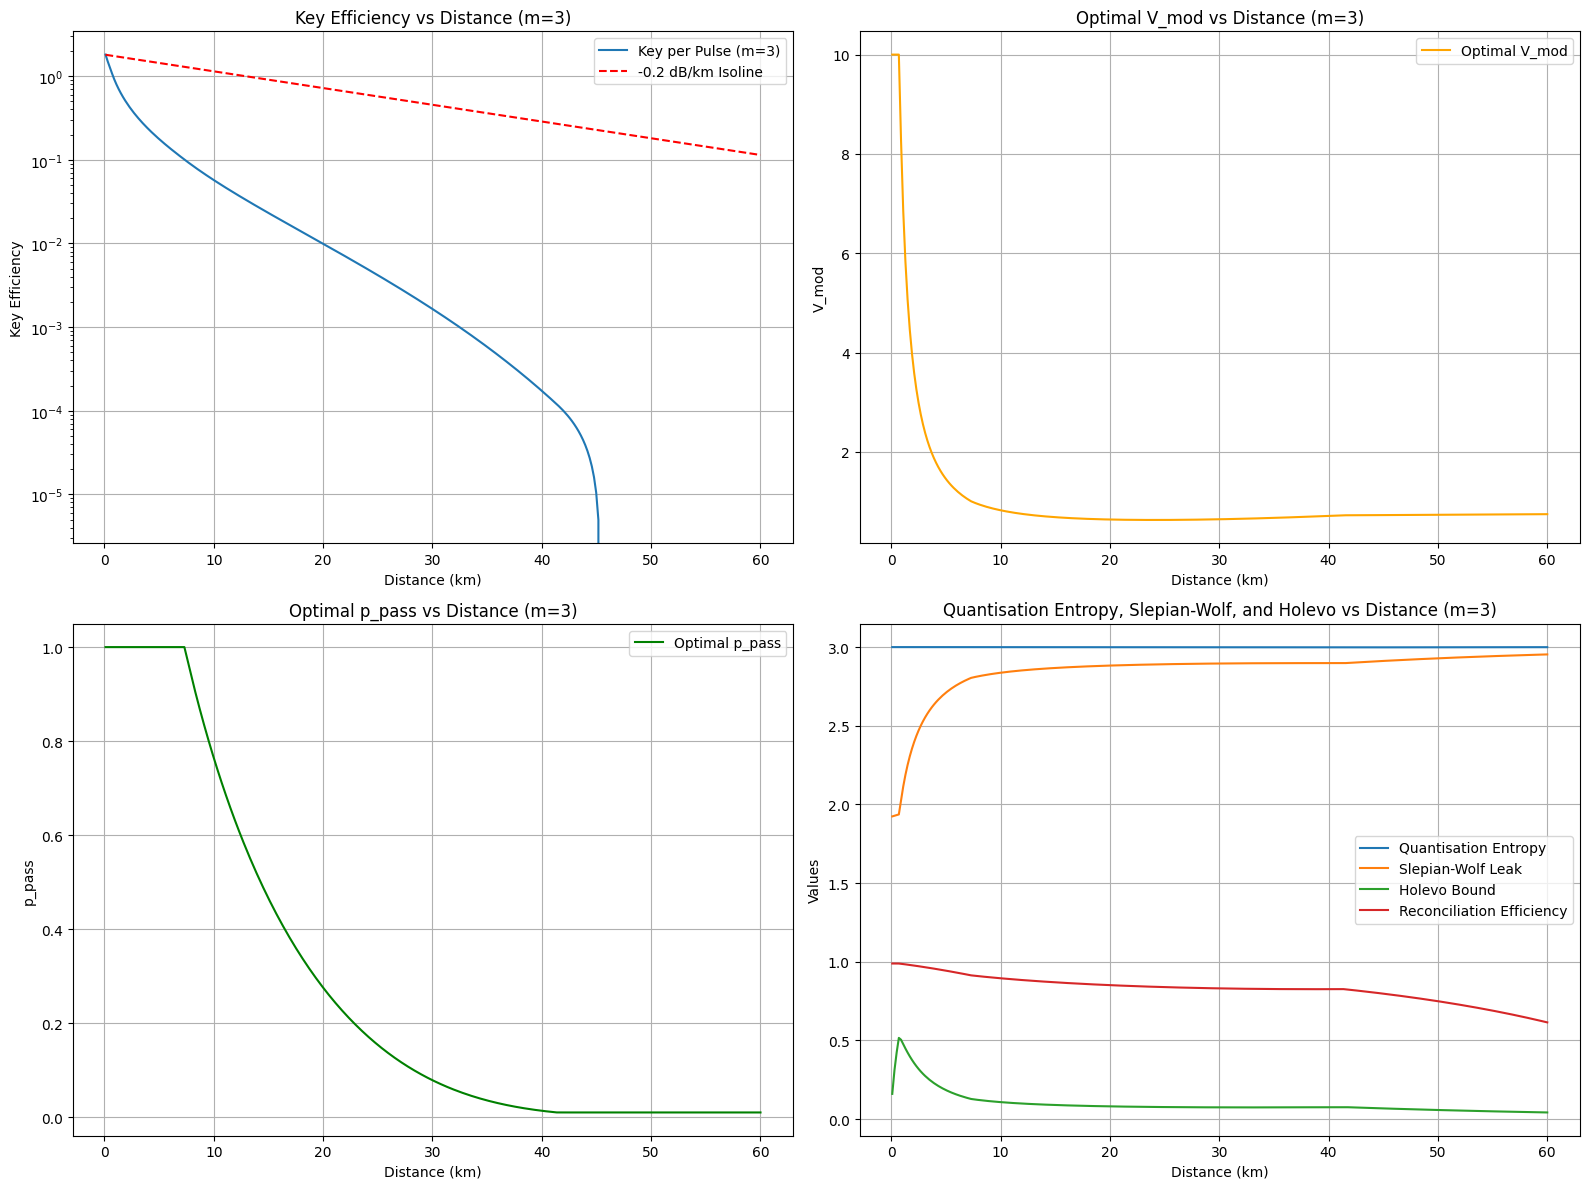

In [43]:
# Optimise m=3 parameters and visualise results, matching previous sections
key_per_pulse_m3 = []
key_per_accepted_m3 = []
quantisation_entropies_m3 = []
slepian_wolf_leaks_m3 = []
holevo_bounds_m3 = []
mutual_informations_m3 = []
devetak_winters_m3 = []
optimal_v_mods_m3 = []
optimal_p_passes_m3 = []
optimal_reconciliation_efficiencies_m3 = []
optimal_metrics_m3 = []

initial_guess_m3 = np.array([np.mean(v_mod_bounds), 0.8])
bounds_m3 = [v_mod_bounds, p_pass_bounds]

for distance in tqdm(distances, desc="Optimising per distance (m=3)"):
    transmittance = fibre_transmittance(distance)

    def evaluate_metrics(v_mod_candidate: float, p_pass_candidate: float):
        gbsr_instance = GBSR(
            3,
            float(v_mod_candidate),
            transmittance,
            excess_noise,
            coding_overhead=m3_coding_overhead_PS,
        )
        tau_arr = gbsr_instance.build_equiprobable_tau()
        g_arr = gbsr_instance.generate_g_arr_from_p_pass(
            float(p_pass_candidate),
            tau_arr,
        )
        metrics = gbsr_instance.evaluate_quantised_maximum_key_efficiency(
            tau_arr,
            g_arr,
        )
        return dict(metrics), gbsr_instance

    def negative_key_per_pulse(params):
        v_mod_candidate, p_pass_candidate = params
        v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
        p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))
        try:
            metrics_candidate, _ = evaluate_metrics(v_mod_checked, p_pass_checked)
        except Exception:
            return np.inf
        value = float(metrics_candidate.get("key_per_pulse", -np.inf))
        if not np.isfinite(value):
            return np.inf
        return -value

    powell_result = minimize(
        negative_key_per_pulse,
        x0=initial_guess_m3,
        method="Powell",
        bounds=bounds_m3,
        options={"xtol": 1e-4, "ftol": 1e-9, "maxiter": 250},
    )

    polish_start = (
        powell_result.x
        if powell_result.success and np.all(np.isfinite(powell_result.x))
        else initial_guess_m3
    )

    polish_result = minimize(
        negative_key_per_pulse,
        x0=polish_start,
        method="L-BFGS-B",
        bounds=bounds_m3,
        options={"maxiter": 200},
    )

    if polish_result.success and np.isfinite(polish_result.fun):
        best_v_mod, best_p_pass = polish_result.x
    elif powell_result.success and np.isfinite(powell_result.fun):
        best_v_mod, best_p_pass = powell_result.x
    else:
        grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
        grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
        best_value = np.inf
        best_pair = None
        for v_candidate in grid_v_mod:
            for p_candidate in grid_p_pass:
                value = negative_key_per_pulse((v_candidate, p_candidate))
                if value < best_value:
                    best_value = value
                    best_pair = (v_candidate, p_candidate)
        if best_pair is None:
            raise RuntimeError(
                f"Failed to find feasible parameters at distance {distance:.2f} km for m=3"
            )
        best_v_mod, best_p_pass = best_pair

    best_v_mod = float(np.clip(best_v_mod, *v_mod_bounds))
    best_p_pass = float(np.clip(best_p_pass, *p_pass_bounds))
    best_metrics, best_gbsr_instance = evaluate_metrics(best_v_mod, best_p_pass)

    key_per_pulse_m3.append(best_metrics["key_per_pulse"])
    key_per_accepted_m3.append(best_metrics["key_per_accepted_symbol"])
    quantisation_entropies_m3.append(best_metrics["H_Tx_acc"])
    slepian_wolf_leaks_m3.append(best_metrics["H_Tx_given_Ty"])
    holevo_bounds_m3.append(best_metrics["holevo_bound"])
    mutual_informations_m3.append(best_metrics["I_symbol"])
    optimal_reconciliation_efficiencies_m3.append(
        best_metrics["reconciliation_efficiency"]
    )
    devetak_winters_m3.append(best_gbsr_instance.continuous_devetak_winter)
    optimal_v_mods_m3.append(best_v_mod)
    optimal_p_passes_m3.append(best_p_pass)
    optimal_metrics_m3.append(best_metrics)

    initial_guess_m3 = np.array([best_v_mod, best_p_pass])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(distances, key_per_pulse_m3, label="Key per Pulse (m=3)")
#axes[0, 0].plot(distances, devetak_winters_m3, label="Devetak-Winter (continuous)")

isoline_m3 = key_per_pulse_m3[0] * 10 ** (-0.2 * distances / 10)
axes[0, 0].plot(distances, isoline_m3, label="-0.2 dB/km Isoline", linestyle="--", color="red")
axes[0, 0].set_xlabel("Distance (km)")
axes[0, 0].set_ylabel("Key Efficiency")
axes[0, 0].set_title("Key Efficiency vs Distance (m=3)")
axes[0, 0].set_yscale("log")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(distances, optimal_v_mods_m3, label="Optimal V_mod", color="orange")
axes[0, 1].set_xlabel("Distance (km)")
axes[0, 1].set_ylabel("V_mod")
axes[0, 1].set_title("Optimal V_mod vs Distance (m=3)")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(distances, optimal_p_passes_m3, label="Optimal p_pass", color="green")
axes[1, 0].set_xlabel("Distance (km)")
axes[1, 0].set_ylabel("p_pass")
axes[1, 0].set_title("Optimal p_pass vs Distance (m=3)")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(distances, quantisation_entropies_m3, label="Quantisation Entropy")
axes[1, 1].plot(distances, slepian_wolf_leaks_m3, label="Slepian-Wolf Leak")
axes[1, 1].plot(distances, holevo_bounds_m3, label="Holevo Bound")
axes[1, 1].plot(distances, optimal_reconciliation_efficiencies_m3, label="Reconciliation Efficiency")
axes[1, 1].set_xlabel("Distance (km)")
axes[1, 1].set_ylabel("Values")
axes[1, 1].set_title("Quantisation Entropy, Slepian-Wolf, and Holevo vs Distance (m=3)")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


# No-Postselection Comparison

Finally, we compare the optimised GBSR discrete with no postselection at all. That is, for each $m = 1, 2, 3$, we optimise only over $V_\text{mod}$ and set $p_\text{pass} = 1$.

Optimising per distance (m=1, p_pass=1):   0%|          | 0/300 [00:00<?, ?it/s]

Optimising per distance (m=2, p_pass=1):   0%|          | 0/300 [00:00<?, ?it/s]

Optimising per distance (m=3, p_pass=1):   0%|          | 0/300 [00:00<?, ?it/s]

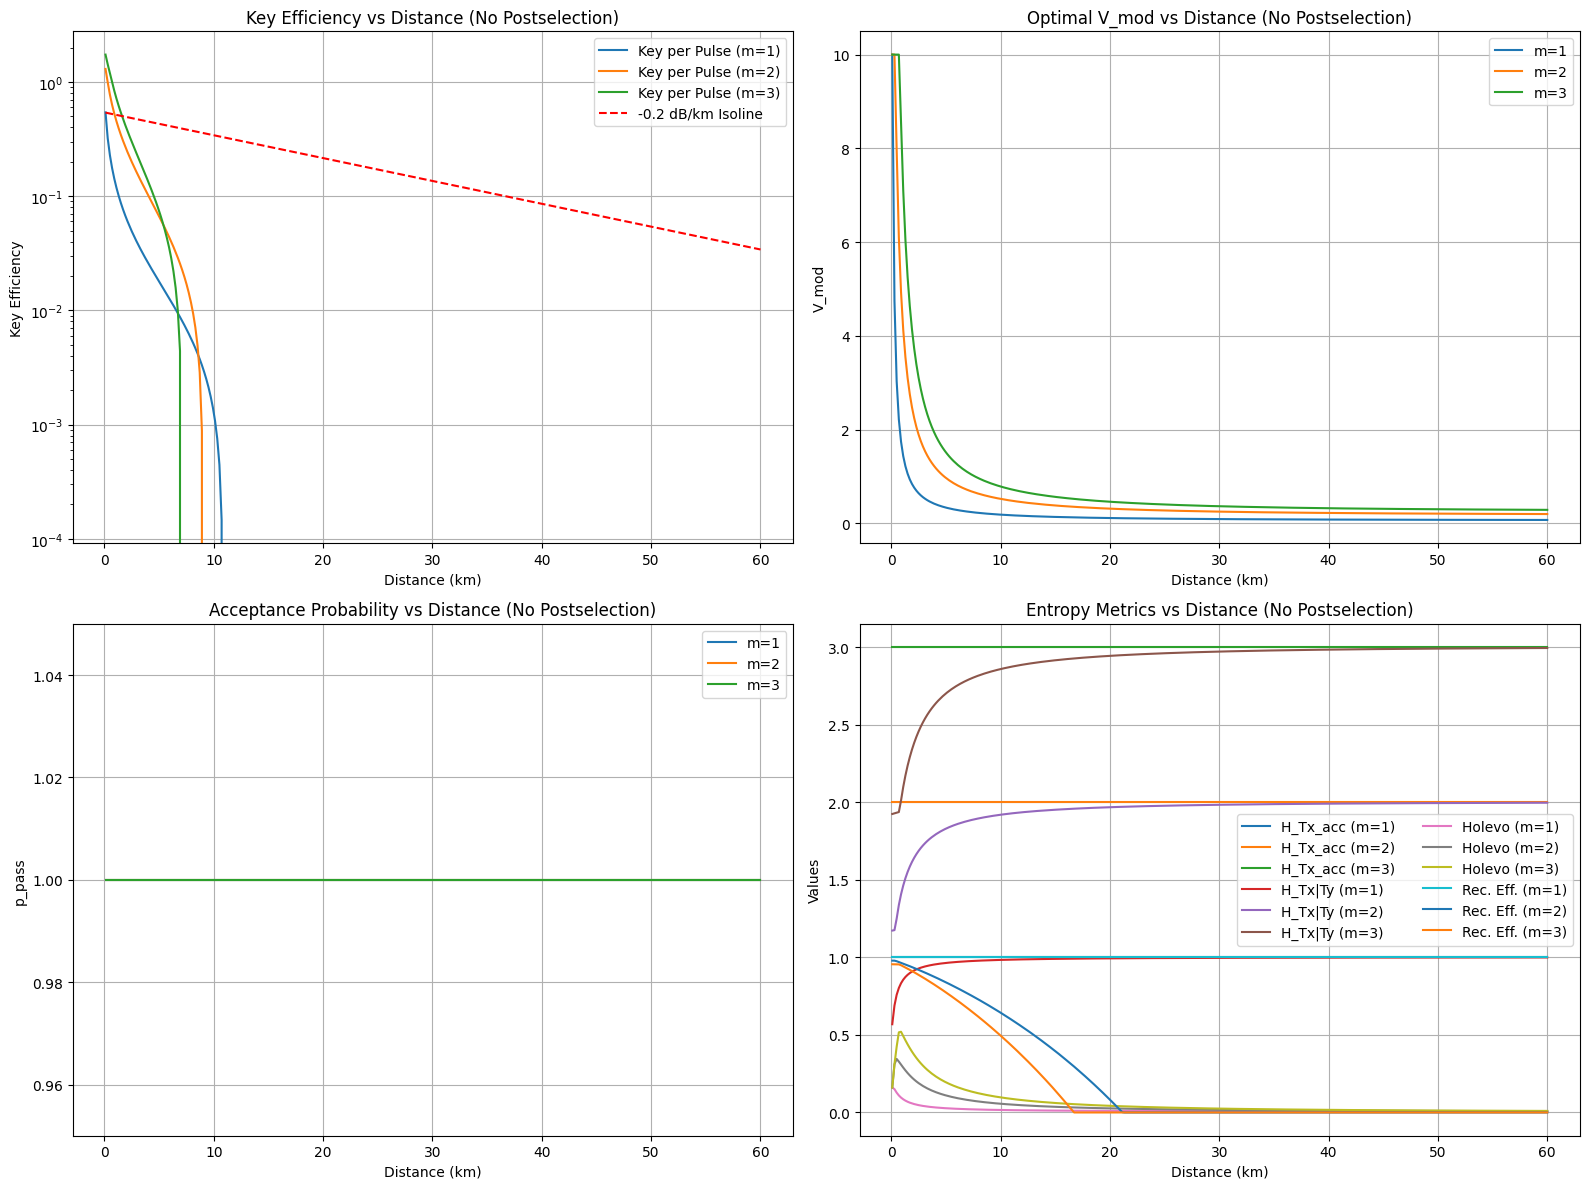

In [44]:
# Compare m = 1, 2, 3 without postselection (p_pass = 1)
key_per_pulse_np_m1 = []
key_per_pulse_np_m2 = []
key_per_pulse_np_m3 = []
key_per_accepted_np_m1 = []
key_per_accepted_np_m2 = []
key_per_accepted_np_m3 = []
quantisation_entropies_np_m1 = []
quantisation_entropies_np_m2 = []
quantisation_entropies_np_m3 = []
slepian_wolf_leaks_np_m1 = []
slepian_wolf_leaks_np_m2 = []
slepian_wolf_leaks_np_m3 = []
holevo_bounds_np_m1 = []
holevo_bounds_np_m2 = []
holevo_bounds_np_m3 = []
mutual_informations_np_m1 = []
mutual_informations_np_m2 = []
mutual_informations_np_m3 = []
devetak_winters_np_m1 = []
devetak_winters_np_m2 = []
devetak_winters_np_m3 = []
optimal_v_mods_np_m1 = []
optimal_v_mods_np_m2 = []
optimal_v_mods_np_m3 = []
optimal_p_passes_np_m1 = []
optimal_p_passes_np_m2 = []
optimal_p_passes_np_m3 = []
optimal_reconciliation_efficiencies_np_m1 = []
optimal_reconciliation_efficiencies_np_m2 = []
optimal_reconciliation_efficiencies_np_m3 = []
optimal_metrics_np_m1 = []
optimal_metrics_np_m2 = []
optimal_metrics_np_m3 = []

results_mapping = {
    1: (
        key_per_pulse_np_m1,
        key_per_accepted_np_m1,
        quantisation_entropies_np_m1,
        slepian_wolf_leaks_np_m1,
        holevo_bounds_np_m1,
        mutual_informations_np_m1,
        devetak_winters_np_m1,
        optimal_v_mods_np_m1,
        optimal_p_passes_np_m1,
        optimal_reconciliation_efficiencies_np_m1,
        optimal_metrics_np_m1,
    ),
    2: (
        key_per_pulse_np_m2,
        key_per_accepted_np_m2,
        quantisation_entropies_np_m2,
        slepian_wolf_leaks_np_m2,
        holevo_bounds_np_m2,
        mutual_informations_np_m2,
        devetak_winters_np_m2,
        optimal_v_mods_np_m2,
        optimal_p_passes_np_m2,
        optimal_reconciliation_efficiencies_np_m2,
        optimal_metrics_np_m2,
    ),
    3: (
        key_per_pulse_np_m3,
        key_per_accepted_np_m3,
        quantisation_entropies_np_m3,
        slepian_wolf_leaks_np_m3,
        holevo_bounds_np_m3,
        mutual_informations_np_m3,
        devetak_winters_np_m3,
        optimal_v_mods_np_m3,
        optimal_p_passes_np_m3,
        optimal_reconciliation_efficiencies_np_m3,
        optimal_metrics_np_m3,
    ),
}

def optimise_no_postselection(m_value: int):
    (
        key_per_pulse_store,
        key_per_accepted_store,
        quantisation_entropy_store,
        slepian_wolf_store,
        holevo_store,
        mutual_information_store,
        devetak_winter_store,
        v_mod_store,
        p_pass_store,
        reconciliation_store,
        metrics_store,
    ) = results_mapping[m_value]

    for distance in tqdm(distances, desc=f"Optimising per distance (m={m_value}, p_pass=1)"):
        transmittance = fibre_transmittance(distance)

        def evaluate_metrics(v_mod_candidate: float):
            if m_value == 1:
                gbsr_instance = GBSR(m_value, float(v_mod_candidate), transmittance, excess_noise, coding_overhead=m1_coding_overhead_no_PS)
            elif m_value == 2:
                gbsr_instance = GBSR(m_value, float(v_mod_candidate), transmittance, excess_noise, coding_overhead=m2_coding_overhead_no_PS)
            else:
                gbsr_instance = GBSR(m_value, float(v_mod_candidate), transmittance, excess_noise, coding_overhead=m3_coding_overhead_no_PS)
            tau_arr = gbsr_instance.build_equiprobable_tau()
            g_arr = gbsr_instance.generate_g_arr_from_p_pass(1.0, tau_arr)
            metrics = gbsr_instance.evaluate_quantised_maximum_key_efficiency(tau_arr, g_arr)
            return dict(metrics), gbsr_instance

        def negative_key_per_pulse(v_mod_candidate: float):
            v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
            try:
                metrics_candidate, _ = evaluate_metrics(v_mod_checked)
            except Exception:
                return np.inf
            return -metrics_candidate["key_per_pulse"]

        optimisation_result = minimize_scalar(
            negative_key_per_pulse,
            bounds=v_mod_bounds,
            method="bounded",
            options={"xatol": 1e-3, "maxiter": 256},
        )

        if not optimisation_result.success or not np.isfinite(optimisation_result.fun):
            grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 75)
            best_value = np.inf
            best_v_mod = None
            for v_candidate in grid_v_mod:
                value = negative_key_per_pulse(float(v_candidate))
                if value < best_value:
                    best_value = value
                    best_v_mod = float(v_candidate)
            if best_v_mod is None:
                raise RuntimeError(f"Failed to find feasible V_mod at distance {distance:.2f} km for m={m_value} with p_pass=1")
        else:
            best_v_mod = float(np.clip(optimisation_result.x, *v_mod_bounds))

        best_metrics, best_gbsr_instance = evaluate_metrics(best_v_mod)

        key_per_pulse_store.append(best_metrics["key_per_pulse"])
        key_per_accepted_store.append(best_metrics["key_per_accepted_symbol"])
        quantisation_entropy_store.append(best_metrics["H_Tx_acc"])
        slepian_wolf_store.append(best_metrics["H_Tx_given_Ty"])
        holevo_store.append(best_metrics["holevo_bound"])
        mutual_information_store.append(best_metrics["I_symbol"])
        reconciliation_store.append(best_metrics["reconciliation_efficiency"])
        devetak_winter_store.append(best_gbsr_instance.continuous_devetak_winter)
        v_mod_store.append(best_v_mod)
        p_pass_store.append(1.0)
        metrics_store.append(best_metrics)

for m_no_postselection in (1, 2, 3):
    optimise_no_postselection(m_no_postselection)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(distances, key_per_pulse_np_m1, label="Key per Pulse (m=1)")
axes[0, 0].plot(distances, key_per_pulse_np_m2, label="Key per Pulse (m=2)")
axes[0, 0].plot(distances, key_per_pulse_np_m3, label="Key per Pulse (m=3)")
isoline_np = key_per_pulse_np_m1[0] * 10 ** (-0.2 * distances / 10)
axes[0, 0].plot(distances, isoline_np, label="-0.2 dB/km Isoline", linestyle="--", color="red")
axes[0, 0].set_xlabel("Distance (km)")
axes[0, 0].set_ylabel("Key Efficiency")
axes[0, 0].set_title("Key Efficiency vs Distance (No Postselection)")
axes[0, 0].set_yscale("log")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(distances, optimal_v_mods_np_m1, label="m=1", color="tab:blue")
axes[0, 1].plot(distances, optimal_v_mods_np_m2, label="m=2", color="tab:orange")
axes[0, 1].plot(distances, optimal_v_mods_np_m3, label="m=3", color="tab:green")
axes[0, 1].set_xlabel("Distance (km)")
axes[0, 1].set_ylabel("V_mod")
axes[0, 1].set_title("Optimal V_mod vs Distance (No Postselection)")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(distances, optimal_p_passes_np_m1, label="m=1", color="tab:blue")
axes[1, 0].plot(distances, optimal_p_passes_np_m2, label="m=2", color="tab:orange")
axes[1, 0].plot(distances, optimal_p_passes_np_m3, label="m=3", color="tab:green")
axes[1, 0].set_xlabel("Distance (km)")
axes[1, 0].set_ylabel("p_pass")
axes[1, 0].set_title("Acceptance Probability vs Distance (No Postselection)")
axes[1, 0].set_ylim(0.95, 1.05)
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(distances, quantisation_entropies_np_m1, label="H_Tx_acc (m=1)")
axes[1, 1].plot(distances, quantisation_entropies_np_m2, label="H_Tx_acc (m=2)")
axes[1, 1].plot(distances, quantisation_entropies_np_m3, label="H_Tx_acc (m=3)")
axes[1, 1].plot(distances, slepian_wolf_leaks_np_m1, label="H_Tx|Ty (m=1)")
axes[1, 1].plot(distances, slepian_wolf_leaks_np_m2, label="H_Tx|Ty (m=2)")
axes[1, 1].plot(distances, slepian_wolf_leaks_np_m3, label="H_Tx|Ty (m=3)")
axes[1, 1].plot(distances, holevo_bounds_np_m1, label="Holevo (m=1)")
axes[1, 1].plot(distances, holevo_bounds_np_m2, label="Holevo (m=2)")
axes[1, 1].plot(distances, holevo_bounds_np_m3, label="Holevo (m=3)")
axes[1, 1].plot(distances, optimal_reconciliation_efficiencies_np_m1, label="Rec. Eff. (m=1)")
axes[1, 1].plot(distances, optimal_reconciliation_efficiencies_np_m2, label="Rec. Eff. (m=2)")
axes[1, 1].plot(distances, optimal_reconciliation_efficiencies_np_m3, label="Rec. Eff. (m=3)")
axes[1, 1].set_xlabel("Distance (km)")
axes[1, 1].set_ylabel("Values")
axes[1, 1].set_title("Entropy Metrics vs Distance (No Postselection)")
axes[1, 1].legend(ncol=2)
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Plot Prototypes and Data for Paper

## Key Efficiency over Distance

TODO: Fix no post-selection curves to appear as expected.

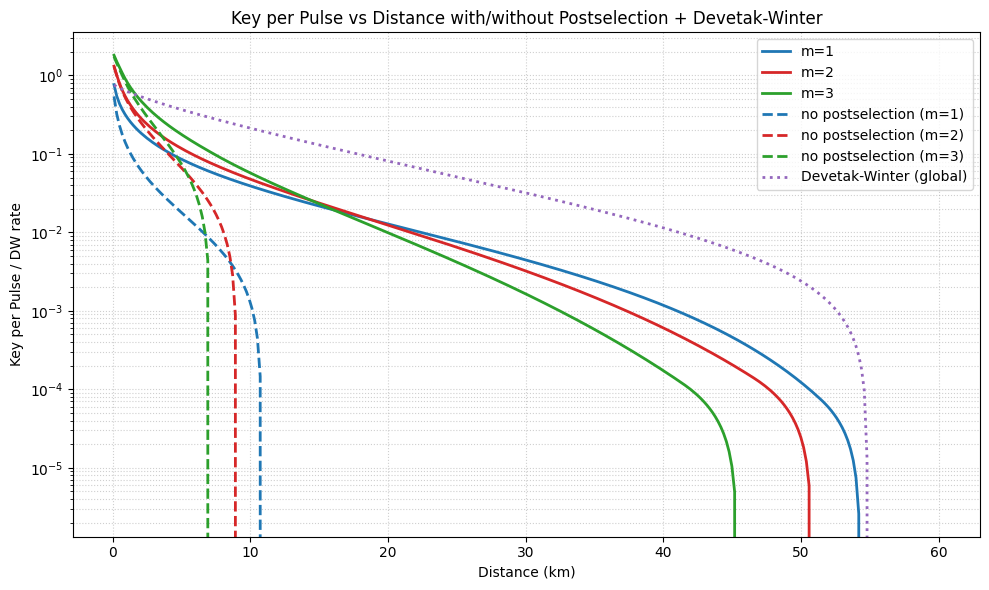

In [45]:
# Overlay key-per-pulse trends (postselection vs no postselection) and the global Devetak-Winter key rate
required_series = [
    key_per_pulse_m1,
    key_per_pulse_m2,
    key_per_pulse_m3,
    key_per_pulse_np_m1,
    key_per_pulse_np_m2,
    key_per_pulse_np_m3,
    dw_key_rates,
 ]
if not all(len(series) == len(distances) and len(series) > 0 for series in required_series):
    raise RuntimeError("Run the optimisation cells (and the DW sanity-check cell) to populate the series before plotting.")

fig, ax = plt.subplots(figsize=(10, 6))
colour_cycle = {
    1: "tab:blue",
    2: "tab:red",
    3: "tab:green",
}

# Key-per-pulse with postselection
for m_value, series in enumerate([key_per_pulse_m1, key_per_pulse_m2, key_per_pulse_m3], start=1):
    ax.plot(distances, series, label=f"m={m_value}", color=colour_cycle[m_value], linewidth=2)

# No postselection key-per-pulse
ax.plot(distances, key_per_pulse_np_m1, label="no postselection (m=1)", color="tab:blue", linestyle="--", linewidth=2)
ax.plot(distances, key_per_pulse_np_m2, label="no postselection (m=2)", color="tab:red", linestyle="--", linewidth=2)
ax.plot(distances, key_per_pulse_np_m3, label="no postselection (m=3)", color="tab:green", linestyle="--", linewidth=2)

# Global Devetak-Winter key rate (optimised over V_mod per distance)
ax.plot(distances, dw_key_rates, label="Devetak-Winter (global)", color="tab:purple", linestyle=":", linewidth=2)

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Key per Pulse / DW rate")
ax.set_title("Key per Pulse vs Distance with/without Postselection + Devetak-Winter")
ax.set_yscale("log")
ax.grid(True, which="both", linestyle=":", alpha=0.6)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


## Optimal $p_\text{pass}$ and $V_\text{mod}$ over Distance for $m = 2$

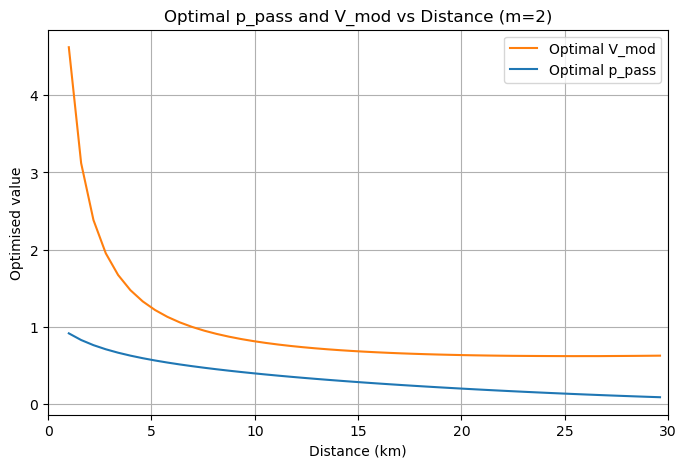

In [ ]:
mask_m2 = distances <= 30
distances_plot = distances[mask_m2]
optimal_p_passes_m2_arr = np.asarray(optimal_p_passes_m2)
optimal_v_mods_m2_arr = np.asarray(optimal_v_mods_m2)
p_pass_plot = optimal_p_passes_m2_arr[mask_m2]
v_mod_plot = optimal_v_mods_m2_arr[mask_m2]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(distances_plot, v_mod_plot, label="Optimal V_mod", color="tab:orange")
ax.plot(distances_plot, p_pass_plot, label="Optimal p_pass", color="tab:blue")
ax.set_xlim(0, 30)
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Optimised value")
ax.set_title("Optimal p_pass and V_mod vs Distance (m=2)")
ax.legend()
ax.grid(True)

plt.show()


## $(V_\text{mod}, p_\text{pass})$ surface for $m = 2$ at 5km

In [ ]:
surface_distance_km = 5
transmittance_surface = fibre_transmittance(surface_distance_km)

v_mod_vals = np.linspace(0.01, 5.0, 20)
p_pass_vals = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 100)
key_surface_m2 = np.full((v_mod_vals.size, p_pass_vals.size), 0.0, dtype=float)

optimal_metrics_m2_surface = None
optimal_indices = (None, None)
best_key_value = -np.inf

for i, v_mod_candidate in tqdm(
    enumerate(v_mod_vals),
    total=v_mod_vals.size,
    desc="Scanning V_mod (m=2)",
    unit="step",
    bar_format="{l_bar}{bar} | {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
):
    gbsr_candidate = GBSR(
        2,
        float(v_mod_candidate),
        transmittance_surface,
        excess_noise,
        # coding_overhead=coding_overhead,
    )
    tau_candidate = gbsr_candidate.build_equiprobable_tau()
    for j, p_pass_candidate in enumerate(p_pass_vals):
        try:
            g_candidate = gbsr_candidate.generate_g_arr_from_p_pass(float(p_pass_candidate), tau_candidate)
            metrics_candidate = gbsr_candidate.evaluate_quantised_maximum_key_efficiency(tau_candidate, g_candidate)
        except Exception:
            continue

        key_val = float(metrics_candidate.get("key_per_pulse", 0.0))
        if key_val < 0.0:
            key_val = 0.0
        key_surface_m2[i, j] = key_val
        if key_val > best_key_value:
            best_key_value = key_val
            optimal_metrics_m2_surface = metrics_candidate
            optimal_indices = (i, j)

if optimal_metrics_m2_surface is None:
    raise RuntimeError("No valid parameter pairs encountered when scanning the m=2 surface.")

best_v_mod = float(v_mod_vals[optimal_indices[0]])
best_p_pass = float(p_pass_vals[optimal_indices[1]])

print(f"Best key per pulse ~= {best_key_value:.3e} at V_mod = {best_v_mod:.3f}, p_pass = {best_p_pass:.3f}")

Scanning V_mod (m=2):   0%|           | 0/20 [00:00<?, ?step/s]

Best key per pulse ~= 1.359e-01 at V_mod = 1.061, p_pass = 0.690


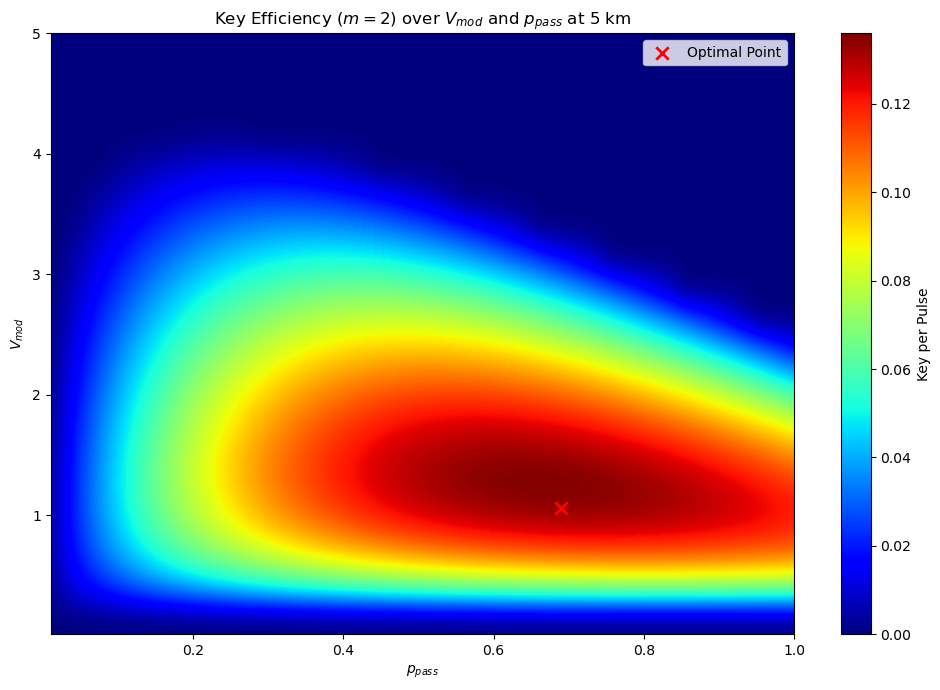

In [ ]:
# Simple imshow representation

fig, ax = plt.subplots(figsize=(10, 7))
image = ax.imshow(
    key_surface_m2,
    extent=(p_pass_vals[0], p_pass_vals[-1], v_mod_vals[0], v_mod_vals[-1]),
    origin="lower",
    aspect="auto",
    cmap="jet",
    interpolation="bicubic",
)
cb = fig.colorbar(image, ax=ax)
cb.set_label("Key per Pulse")
ax.scatter(best_p_pass, best_v_mod, color="red", marker="x", s=80, linewidths=2, label="Optimal Point")
ax.set_title("Key Efficiency ($m = 2$) over $V_{mod}$ and $p_{pass}$ at 5 km")
ax.set_xlabel("$p_{pass}$")
ax.set_ylabel("$V_{mod}$")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

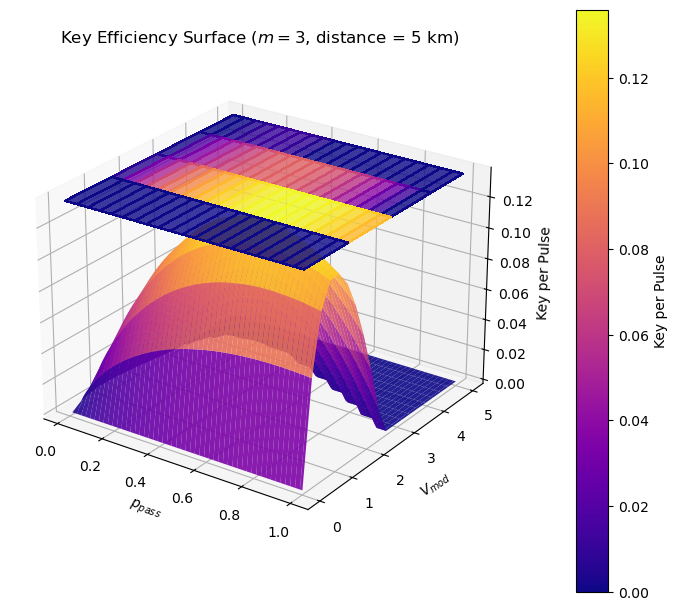

WILL MAKE NICER IN LATEX IN PAPER


In [ ]:
# Example data setup (replace with your own arrays)
# p_pass_vals, v_mod_vals, key_surface_m2 = ...
P_pass_grid, V_mod_grid = np.meshgrid(p_pass_vals, v_mod_vals)

fig = plt.figure(figsize=(7, 10))
ax = fig.add_subplot(111, projection="3d")

# Main surface
surface = ax.plot_surface(
    P_pass_grid,
    V_mod_grid,
    key_surface_m2,
    cmap="plasma",
    linewidth=0,
    antialiased=True,
    alpha=0.9,
)

# ----- Add projection onto the *top plane* -----
# Define the z height of the projection
z_top = np.nanmax(key_surface_m2)

# Normalize data to [0,1] for color mapping
norm = plt.Normalize(np.nanmin(key_surface_m2), np.nanmax(key_surface_m2))
colors = plt.cm.plasma(norm(key_surface_m2))

# Plot a copy of the surface but at constant z = z_top
ax.plot_surface(
    P_pass_grid,
    V_mod_grid,
    z_top * np.ones_like(key_surface_m2),
    facecolors=colors,
    rstride=5, cstride=5,
    antialiased=False,
    alpha=0.8,        # transparency of projection
    shade=False,
)

# -----------------------------------------------

ax.set_xlabel("$p_{pass}$")
ax.set_ylabel("$V_{mod}$")
ax.set_zlabel("Key per Pulse")
ax.set_title("Key Efficiency Surface ($m = 3$, distance = 5 km)")
ax.view_init(elev=25, azim=-55)

# Colorbar (matches both surfaces)
# Create the mappable for colorbar
mappable = plt.cm.ScalarMappable(cmap="plasma", norm=norm)
mappable.set_array([])

# Add colorbar to the same axes
fig.colorbar(
    mappable,
    ax=ax,               # <---- this line fixes the error
    shrink=0.6,
    aspect=18,
    pad=0.1,
    label="Key per Pulse",
)
plt.tight_layout()
plt.show()

print("WILL MAKE NICER IN LATEX IN PAPER")

## $m = 1$ possible key rates over distance, with $\delta_\text{ch} = 10^{-9}, 10^{-6}, 10^{-3}$

TODO: Instability is due to coarse t optimisation I think. Should make that more rigourous?
TODO: 1e-3 curvs ends very early for some reason?
TODO: Also include \delta_ch = 0

In [25]:
# Sanity checks for continuity correction and boundary behaviour
sanity_distance_km = 10.0
sanity_v_mod = 2.0
sanity_delta_ch = 1e-6
p_pass_scan = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 41)

per_symbol_gaps = []
per_accepted_gaps = []
reference_two_delta = []
p_pass_record = []

for p_target in tqdm(p_pass_scan, desc="Sanity sweep p_pass"):
    gbsr = GBSR(
        1,
        sanity_v_mod,
        fibre_transmittance(sanity_distance_km),
        excess_noise,
        coding_overhead=coding_overhead,
    )
    tau_arr = gbsr.build_equiprobable_tau()
    g_arr = gbsr.generate_g_arr_from_p_pass(float(p_target), tau_arr)

    gbsr.Delta_QCT = 0.0
    gaussian_metrics = gbsr.evaluate_quantised_maximum_key_efficiency(tau_arr, g_arr)

    delta_info = gbsr.set_delta_qct_from_delta_ch(sanity_delta_ch, tau_arr, g_arr)
    corrected_metrics = gbsr.evaluate_quantised_maximum_key_efficiency(tau_arr, g_arr)

    per_symbol_gaps.append(
        float(gaussian_metrics["key_per_symbol"]) - float(corrected_metrics["key_per_symbol"])
    )
    per_accepted_gaps.append(
        float(gaussian_metrics["key_per_accepted_symbol"]) - float(corrected_metrics["key_per_accepted_symbol"])
    )
    reference_two_delta.append(float(delta_info["two_delta"]))
    p_pass_record.append(float(corrected_metrics["p_pass"]))

per_symbol_gaps = np.asarray(per_symbol_gaps, dtype=float)
per_accepted_gaps = np.asarray(per_accepted_gaps, dtype=float)
reference_two_delta = np.asarray(reference_two_delta, dtype=float)
p_pass_record = np.asarray(p_pass_record, dtype=float)

symbol_gap_residual = np.max(np.abs(per_symbol_gaps - reference_two_delta))
accepted_gap_residual = np.max(
    np.abs(per_accepted_gaps - reference_two_delta / np.clip(p_pass_record, 1e-12, 1.0))
)

print(f"Per-symbol gap residual vs 2*Delta_ch: {symbol_gap_residual:.3e}")
print(f"Per-accepted-symbol gap residual vs 2*Delta_ch/p_pass: {accepted_gap_residual:.3e}")

boundary_gbsr = GBSR(
    1,
    sanity_v_mod,
    fibre_transmittance(sanity_distance_km),
    excess_noise,
    coding_overhead=coding_overhead,
)
tau_boundary = boundary_gbsr.build_equiprobable_tau()
g_boundary = boundary_gbsr.generate_g_arr_from_p_pass(1.0, tau_boundary)

cov_beta_acc = boundary_gbsr.evaluate_cov_beta_acc(tau_boundary, g_boundary)
_, v_y_EB, _ = boundary_gbsr._channel_gaussian_parameters()
print(
    "Cov(beta | acc) diagonal:", cov_beta_acc[0, 0], cov_beta_acc[1, 1],
)
print("Unconditional v_y_EB:", v_y_EB)
print(
    "Boundary variance residual:",
    float(np.max(np.abs(np.array([cov_beta_acc[0, 0], cov_beta_acc[1, 1]]) - v_y_EB))),
)


Sanity sweep p_pass:   0%|          | 0/41 [00:00<?, ?it/s]

Per-symbol gap residual vs 2*Delta_ch: 2.296e-17
Per-accepted-symbol gap residual vs 2*Delta_ch/p_pass: 4.619e-17
Cov(beta | acc) diagonal: 3.2629146889603864 3.2629146889603864
Unconditional v_y_EB: 3.2629146889603864
Boundary variance residual: 0.0


In [3]:
delta_ch_values = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]

key_per_pulse_m1_delta = {}
key_per_accepted_symbol_m1_delta = {}
optimal_v_mods_m1_delta = {}
optimal_p_passes_m1_delta = {}
two_delta_m1_delta = {}

for delta_ch in delta_ch_values:
    key_per_pulse_series = []
    key_per_accepted_series = []
    optimal_v_series = []
    optimal_p_series = []
    two_delta_series = []

    initial_guess = np.array([np.mean(v_mod_bounds), 0.8])

    progress_desc = f"delta_ch={delta_ch:.0e} optimisation"
    for distance in tqdm(distances, desc=progress_desc):
        transmittance = fibre_transmittance(distance)

        def evaluate_candidate(v_mod_candidate, p_pass_candidate):
            v_mod_checked = float(np.clip(v_mod_candidate, *v_mod_bounds))
            p_pass_checked = float(np.clip(p_pass_candidate, *p_pass_bounds))

            gbsr_instance = GBSR(
                1,
                v_mod_checked,
                transmittance,
                excess_noise,
                coding_overhead=coding_overhead,
            )
            tau_arr = gbsr_instance.build_equiprobable_tau()
            g_arr = gbsr_instance.generate_g_arr_from_p_pass(p_pass_checked, tau_arr)

            delta_info = gbsr_instance.set_delta_qct_from_delta_ch(
                delta_ch,
                tau_arr,
                g_arr,
            )
            metrics = gbsr_instance.evaluate_quantised_maximum_key_efficiency(tau_arr, g_arr)

            return {
                "metrics": metrics,
                "delta_info": delta_info,
                "v_mod": v_mod_checked,
                "p_pass": p_pass_checked,
            }

        def negative_corrected_key(params):
            try:
                evaluation = evaluate_candidate(*params)
            except Exception:
                return np.inf
            metrics = evaluation["metrics"]
            value = float(metrics.get("key_per_pulse", -np.inf))
            if not np.isfinite(value):
                return np.inf
            return -value

        powell_result = minimize(
            negative_corrected_key,
            x0=initial_guess,
            method="Powell",
            bounds=[v_mod_bounds, p_pass_bounds],
            options={"xtol": 1e-4, "ftol": 1e-9, "maxiter": 250},
        )

        polish_start = (
            powell_result.x
            if powell_result.success and np.all(np.isfinite(powell_result.x))
            else initial_guess
        )

        polish_result = minimize(
            negative_corrected_key,
            x0=polish_start,
            method="L-BFGS-B",
            bounds=[v_mod_bounds, p_pass_bounds],
            options={"maxiter": 200},
        )

        if polish_result.success and np.isfinite(polish_result.fun):
            best_v_mod, best_p_pass = polish_result.x
        elif powell_result.success and np.isfinite(powell_result.fun):
            best_v_mod, best_p_pass = powell_result.x
        else:
            grid_v_mod = np.linspace(v_mod_bounds[0], v_mod_bounds[1], 25)
            grid_p_pass = np.linspace(p_pass_bounds[0], p_pass_bounds[1], 25)
            best_value = np.inf
            best_params = None
            for v_candidate in grid_v_mod:
                for p_candidate in grid_p_pass:
                    value = negative_corrected_key((v_candidate, p_candidate))
                    if value < best_value:
                        best_value = value
                        best_params = (v_candidate, p_candidate)
            if best_params is None:
                raise RuntimeError(
                    f"Failed to find feasible parameters at distance {distance:.2f} km for delta_ch={delta_ch:.0e}"
                )
            best_v_mod, best_p_pass = best_params

        evaluation = evaluate_candidate(best_v_mod, best_p_pass)
        metrics = evaluation["metrics"]
        delta_info = evaluation["delta_info"]

        key_value = float(metrics.get("key_per_pulse", 0.0))
        if key_value < 0.0:
            key_value = 0.0
        key_per_pulse_series.append(key_value)
        key_per_accepted_series.append(float(metrics.get("key_per_accepted_symbol", 0.0)))
        two_delta_series.append(float(delta_info.get("two_delta", 0.0)))
        optimal_v_series.append(evaluation["v_mod"])
        optimal_p_series.append(evaluation["p_pass"])

        initial_guess = np.array([evaluation["v_mod"], evaluation["p_pass"]])

    key_per_pulse_m1_delta[delta_ch] = key_per_pulse_series
    key_per_accepted_symbol_m1_delta[delta_ch] = key_per_accepted_series
    optimal_v_mods_m1_delta[delta_ch] = optimal_v_series
    optimal_p_passes_m1_delta[delta_ch] = optimal_p_series
    two_delta_m1_delta[delta_ch] = two_delta_series

delta_ch=0e+00 optimisation:   0%|          | 0/300 [00:00<?, ?it/s]

delta_ch=1e-06 optimisation:   0%|          | 0/300 [00:00<?, ?it/s]

delta_ch=1e-05 optimisation:   0%|          | 0/300 [00:00<?, ?it/s]

delta_ch=1e-04 optimisation:   0%|          | 0/300 [00:00<?, ?it/s]

delta_ch=1e-03 optimisation:   0%|          | 0/300 [00:00<?, ?it/s]

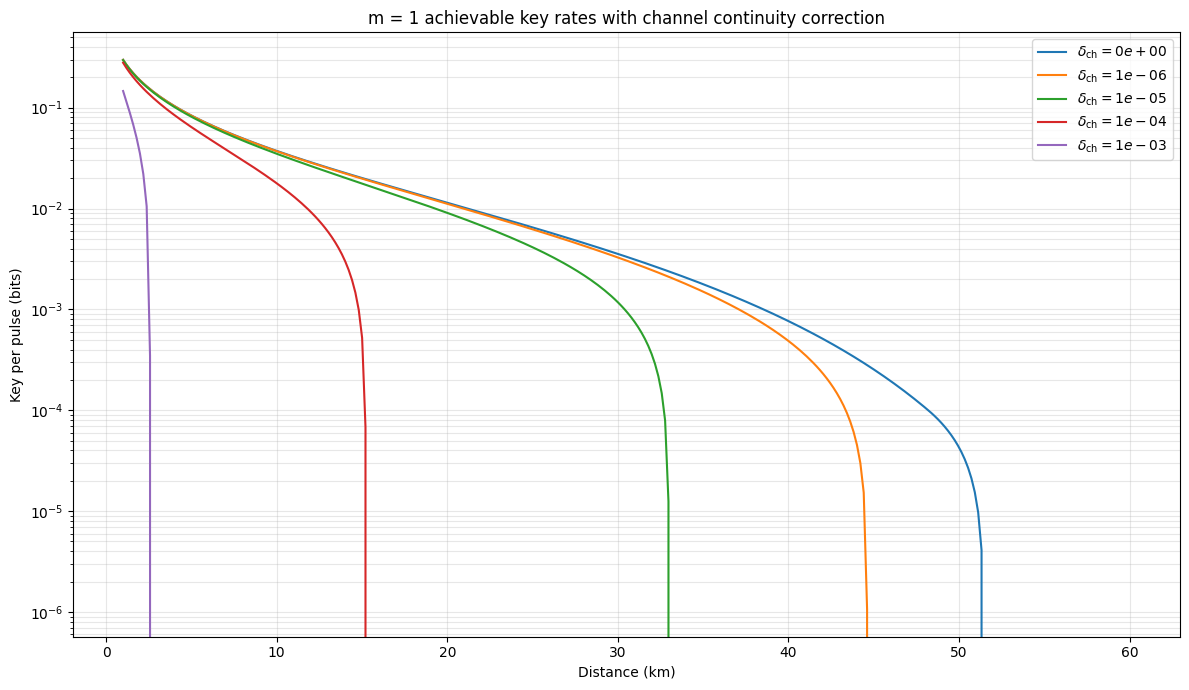

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))
for delta_ch, key_series in key_per_pulse_m1_delta.items():
    key_arr = np.asarray(key_series, dtype=float)
    label = "$\\delta_{\\mathrm{ch}} = " + f"{delta_ch:.0e}$"
    ax.plot(distances, key_arr, label=label)
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Key per pulse (bits)")
ax.set_title("m = 1 achievable key rates with channel continuity correction")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Exporting Data

In [49]:
import pandas as pd
from pathlib import Path

output_dir = (Path.cwd() / "plotting_data").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

def _ensure_series(name, values, expected_length=None):
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        raise RuntimeError(f"Series '{name}' is empty; run prerequisite optimisation cells first.")
    if expected_length is not None and arr.size != expected_length:
        raise RuntimeError(
            f"Series '{name}' has length {arr.size}, expected {expected_length}."
        )
    return arr

distances_arr = _ensure_series("distances", distances)

# --- Key-per-pulse curves (with and without postselection) and DW sanity-check
key_per_pulse_df = pd.DataFrame({
    "distance_km": distances_arr,
    "key_per_pulse_m1_postselection": _ensure_series(
        "key_per_pulse_m1", key_per_pulse_m1, distances_arr.size
    ),
    "key_per_pulse_m2_postselection": _ensure_series(
        "key_per_pulse_m2", key_per_pulse_m2, distances_arr.size
    ),
    "key_per_pulse_m3_postselection": _ensure_series(
        "key_per_pulse_m3", key_per_pulse_m3, distances_arr.size
    ),
    "key_per_pulse_m1_no_post": _ensure_series(
        "key_per_pulse_np_m1", key_per_pulse_np_m1, distances_arr.size
    ),
    "key_per_pulse_m2_no_post": _ensure_series(
        "key_per_pulse_np_m2", key_per_pulse_np_m2, distances_arr.size
    ),
    "key_per_pulse_m3_no_post": _ensure_series(
        "key_per_pulse_np_m3", key_per_pulse_np_m3, distances_arr.size
    ),
    "devetak_winter_vmod_2p2": _ensure_series(
        "dw_key_rates", dw_key_rates, distances_arr.size
    ),
})
key_per_pulse_path = output_dir / "key_per_pulse_post_vs_no_post_m123_2.dat"
key_per_pulse_df.to_csv(key_per_pulse_path, sep="	", index=False, float_format="%.8e")

# # --- Optimised m = 2 parameters (restricted to <= 30 km for clarity)
# optimal_v_mods_m2_arr = _ensure_series(
#     "optimal_v_mods_m2", optimal_v_mods_m2, distances_arr.size
# )
# optimal_p_passes_m2_arr = _ensure_series(
#     "optimal_p_passes_m2", optimal_p_passes_m2, distances_arr.size
# )
# mask_m2 = distances_arr <= 30.0
# optimal_params_m2_df = pd.DataFrame({
#     "distance_km": distances_arr[mask_m2],
#     "optimal_v_mod": optimal_v_mods_m2_arr[mask_m2],
#     "optimal_p_pass": optimal_p_passes_m2_arr[mask_m2],
# })
# optimal_params_path = output_dir / "optimal_params_m2_distance_upto_30km.dat"
# optimal_params_m2_df.to_csv(optimal_params_path, sep="	", index=False, float_format="%.8e")

# # --- m = 2 key-efficiency surface at 5 km (tidy format)
# key_surface_m2_arr = np.asarray(key_surface_m2, dtype=float)
# if key_surface_m2_arr.size == 0:
#     raise RuntimeError("'key_surface_m2' is empty; run the surface evaluation cell first.")
# v_mod_vals_arr = _ensure_series(
#     "v_mod_vals", v_mod_vals, key_surface_m2_arr.shape[0]
# )
# p_pass_vals_arr = _ensure_series(
#     "p_pass_vals", p_pass_vals, key_surface_m2_arr.shape[1]
# )
# P_pass_grid, V_mod_grid = np.meshgrid(p_pass_vals_arr, v_mod_vals_arr)
# key_surface_df = pd.DataFrame({
#     "p_pass": P_pass_grid.ravel(),
#     "v_mod": V_mod_grid.ravel(),
#     "key_per_pulse": key_surface_m2_arr.ravel(),
# })
# key_surface_path = output_dir / "key_efficiency_surface_m2_distance_5km.dat"
# key_surface_df.to_csv(key_surface_path, sep="	", index=False, float_format="%.8e")

# print("Exported:")
# for path in (key_per_pulse_path, optimal_params_path, key_surface_path):
#     print(f"  - {path}")


In [ ]:
# from pathlib import Path

# # Export δ_ch-dependent optimisation traces produced in the previous cell.
# output_dir = (Path.cwd() / "plotting_data").resolve()
# output_dir.mkdir(parents=True, exist_ok=True)

# def _ensure_series(name, values, expected_length=None):
#     arr = np.asarray(values, dtype=float)
#     if arr.size == 0:
#         raise RuntimeError(f"Series '{name}' is empty; rerun the δ_ch optimisation cell first.")
#     if expected_length is not None and arr.size != expected_length:
#         raise RuntimeError(
#             f"Series '{name}' has length {arr.size}, expected {expected_length}."
#         )
#     return arr

# def _format_delta(delta):
#     return f"{delta:.0e}"

# def _ensure_delta_dict(name, data_dict, expected_length):
#     if not data_dict:
#         raise RuntimeError(f"Dictionary '{name}' is empty; rerun the δ_ch optimisation cell.")
#     headers = []
#     columns = []
#     for delta in delta_ch_values:
#         if delta not in data_dict:
#             raise RuntimeError(f"Dictionary '{name}' is missing the entry for δ_ch={delta:.0e}.")
#         series = _ensure_series(f"{name}[{delta:.0e}]", data_dict[delta], expected_length)
#         headers.append(_format_delta(delta))
#         columns.append(series)
#     return headers, columns

# def _write_delta_series(filename, descriptor, data_dict, distances_arr):
#     headers, columns = _ensure_delta_dict(descriptor, data_dict, distances_arr.size)
#     export_matrix = np.column_stack([distances_arr] + columns)
#     header = "\t".join(["distance_km"] + [f"{descriptor}_{tag}" for tag in headers])
#     np.savetxt(
#         output_dir / filename,
#         export_matrix,
#         delimiter="\t",
#         header=header,
#         comments="",
#         fmt="%.8e",
#     )

# distances_arr = _ensure_series("distances", distances)

# _write_delta_series(
#     "m1_key_per_pulse_delta_ch.dat",
#     "key_per_pulse",
#     key_per_pulse_m1_delta,
#     distances_arr,
# )

# _write_delta_series(
#     "m1_key_per_accepted_symbol_delta_ch.dat",
#     "key_per_accepted_symbol",
#     key_per_accepted_symbol_m1_delta,
#     distances_arr,
# )

# _write_delta_series(
#     "m1_two_delta_delta_ch.dat",
#     "two_delta",
#     two_delta_m1_delta,
#     distances_arr,
# )

# _write_delta_series(
#     "m1_optimal_v_mod_delta_ch.dat",
#     "optimal_v_mod",
#     optimal_v_mods_m1_delta,
#     distances_arr,
# )

# _write_delta_series(
#     "m1_optimal_p_pass_delta_ch.dat",
#     "optimal_p_pass",
#     optimal_p_passes_m1_delta,
#     distances_arr,
# )

# print("Prepared δ_ch export files in:", output_dir)

Prepared δ_ch export files in: C:\Users\Adam\OneDrive - University of Cambridge\PhD\Projects\CVQKD Postselection and Security\CVQKD_guard-band_postselection\guard_band_postselection_new\plotting_data
